# TCN Regression Training (Phase 2B)

Train a TCN regressor on punch clips to predict peak force (N) and peak speed (m/s).

**Inputs:**
- Punch clips: `data/clips/with_hardware/{class}/{clip_id}.npy`
- Labels: `data/metadata/with_hardware/labels.csv`

**Architecture:** Same TCN as Phase 2A, with two changes:
- Body weight scalar concatenated at the FC layer
- Output: 2 regression values (force, speed) instead of 5 class probabilities
- Loss: MSE

In [1]:
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu130


## Configuration

In [2]:
PROJECT_ROOT = Path("../../")

CLIPS_DIR = PROJECT_ROOT / "data" / "clips" / "with_hardware"
LABELS_CSV = PROJECT_ROOT / "data" / "metadata" / "with_hardware" / "labels.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "tcn_regression"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Model hyperparameters
T = 48                       # window size (frames)
N_JOINTS = 9
N_CHANNELS = 3
N_FEATURES = N_JOINTS * N_CHANNELS   # flattened input dimension

# Training hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100
SEED = 42

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Loading labels from: {LABELS_CSV}")
labels_df = pd.read_csv(LABELS_CSV)
print(f"Total clips: {len(labels_df)}")
print(f"Subjects: {sorted(labels_df['subject_id'].unique())}")
print(f"Classes: {sorted(labels_df['class'].unique())}")

Loading labels from: ../../data/metadata/with_hardware/labels.csv
Total clips: 561
Subjects: ['subject01', 'subject02', 'subject03']
Classes: ['cross', 'hook', 'jab', 'uppercut']


## Dataset Class

Loads each punch clip plus its body weight and regression targets.
Applies temporal augmentation (random window placement) during training.

In [3]:
class PunchRegressionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, clips_dir: Path, augment: bool = True):
        self.df = df.reset_index(drop=True)
        self.clips_dir = clips_dir
        self.augment = augment
    
    def __len__(self):
        return len(self.df)
    
    def _pad_or_truncate(self, clip: np.ndarray) -> np.ndarray:
        """Pad or truncate clip to T frames, with optional temporal augmentation."""
        L = clip.shape[0]
        
        if L >= T:
            # Clip is longer than T, just truncate to first T frames
            return clip[:T]
        
        # Clip is shorter than T, need to pad
        if self.augment:
            # Random offset placement
            max_offset = T - L
            offset = random.randint(0, max_offset)
        else:
            offset = 0  # deterministic: clip at start
        
        # Build full T-frame window
        full = np.zeros((T, N_JOINTS, N_CHANNELS), dtype=np.float32)
        
        # Pre-padding: replicate first frame
        if offset > 0:
            full[:offset] = clip[0]
        
        # Place clip
        full[offset:offset + L] = clip
        
        # Post-padding: replicate last frame
        if offset + L < T:
            full[offset + L:] = clip[-1]
        
        return full
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_path = self.clips_dir / row["class"] / f"{row['clip_id']}.npy"
        
        clip = np.load(clip_path).astype(np.float32)
        clip = self._pad_or_truncate(clip)
        
        # Reshape to (N_FEATURES, T) for TCN input
        clip = clip.reshape(T, -1).T  # (N_FEATURES, T)
        clip_tensor = torch.from_numpy(clip).float()
        
        # Body weight (auxiliary input)
        body_weight = torch.tensor(row["body_weight_kg"], dtype=torch.float32)
        
        # Targets: force, speed
        targets = torch.tensor([
            row["peak_force_N"],
            row["peak_speed_mps"]
        ], dtype=torch.float32)
        
        return clip_tensor, body_weight, targets


# Verify
ds = PunchRegressionDataset(labels_df, CLIPS_DIR, augment=False)
clip, weight, targets = ds[0]
print(f"Dataset created with {len(ds)} samples")
print(f"Clip shape: {clip.shape} (expecting (27, 48))")
print(f"Body weight shape: {weight.shape}, value: {weight.item():.1f} kg")
print(f"Targets shape: {targets.shape}, values: force={targets[0].item():.1f}N, speed={targets[1].item():.2f}m/s")

Dataset created with 561 samples
Clip shape: torch.Size([27, 48]) (expecting (27, 48))
Body weight shape: torch.Size([]), value: 58.0 kg
Targets shape: torch.Size([2]), values: force=171.0N, speed=3.67m/s


## TCN Regression Architecture

Same TCN as Phase 2A classification, but:
- 2-output regression head instead of 5-class softmax
- Body weight scalar concatenated before the final FC layer

In [4]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        res = self.residual(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        x = self.relu(x + res)
        x = self.dropout(x)
        return x


class TCNRegressor(nn.Module):
    def __init__(self, in_channels=N_FEATURES, channels=[64, 128, 256],
                 kernel_size=5, dropout=0.2, n_outputs=2):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(in_channels)
        layers = []
        prev_channels = in_channels
        for i, ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TCNBlock(prev_channels, ch, kernel_size, dilation, dropout))
            prev_channels = ch
        self.tcn = nn.Sequential(*layers)
        
        # FC head with body weight concatenated
        self.fc = nn.Sequential(
            nn.Linear(prev_channels + 1, 64),   # +1 for body weight
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_outputs),
        )
    
    def forward(self, x, body_weight):
        """
        x: (B, N_FEATURES, T)
        body_weight: (B,) — scalar body weight per sample
        """
        x = self.data_bn(x)
        x = self.tcn(x)
        x = x.mean(dim=2)  # global average pool over time: (B, channels)
        
        # Concatenate body weight as additional feature
        body_weight = body_weight.unsqueeze(1)  # (B, 1)
        x = torch.cat([x, body_weight], dim=1)
        
        x = self.fc(x)  # (B, n_outputs)
        return x


# Test the model
model = TCNRegressor().to(DEVICE)
clip_tensor, weight_tensor, _ = ds[0]
clip_batch = clip_tensor.unsqueeze(0).to(DEVICE)
weight_batch = weight_tensor.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    output = model(clip_batch, weight_batch)
print(f"Model output shape: {output.shape} (expecting (1, 2))")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([1, 2]) (expecting (1, 2))
Parameters: 706,040


## Training Loop

One pass — single split for initial debugging. Cross-validation comes later.
For now, hold out one subject as test set; train on the rest.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device, target_mean, target_std):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for clip, weight, target in loader:
        clip, weight, target = clip.to(device), weight.to(device), target.to(device)
        
        # Normalize targets
        target_norm = (target - target_mean) / target_std
        
        optimizer.zero_grad()
        pred = model(clip, weight)
        loss = criterion(pred, target_norm)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * clip.size(0)
        n_samples += clip.size(0)
    
    return total_loss / n_samples


def evaluate(model, loader, criterion, device, target_mean, target_std):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for clip, weight, target in loader:
            clip, weight, target = clip.to(device), weight.to(device), target.to(device)
            
            # Normalize targets for loss computation
            target_norm = (target - target_mean) / target_std
            
            pred = model(clip, weight)
            loss = criterion(pred, target_norm)
            
            # Denormalize predictions for metrics
            pred_unnorm = pred * target_std + target_mean
            
            total_loss += loss.item() * clip.size(0)
            n_samples += clip.size(0)
            all_preds.append(pred_unnorm.cpu().numpy())
            all_targets.append(target.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    return total_loss / n_samples, all_preds, all_targets

def compute_metrics(preds: np.ndarray, targets: np.ndarray) -> dict:
    """Per-output metrics: MAE, RMSE, R²."""
    metrics = {}
    output_names = ["force_N", "speed_mps"]
    for i, name in enumerate(output_names):
        metrics[f"{name}_mae"] = mean_absolute_error(targets[:, i], preds[:, i])
        metrics[f"{name}_rmse"] = np.sqrt(mean_squared_error(targets[:, i], preds[:, i]))
        metrics[f"{name}_r2"] = r2_score(targets[:, i], preds[:, i])
    return metrics

## Single-Split Training (Subject Held Out)

For initial debugging, hold out the last subject. Once this works,
we'll do proper subject-level cross-validation.

In [6]:
# Switch: True for code testing on single subject, False for real subject-level evaluation
USE_RANDOM_SPLIT_FOR_TESTING = True

if USE_RANDOM_SPLIT_FOR_TESTING:
    # Random 80/20 split — NOT a valid scientific evaluation, just for code sanity check
    shuffled_df = labels_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_size = int(len(shuffled_df) * 0.2)
    test_df = shuffled_df[:test_size]
    train_df = shuffled_df[test_size:]
    print(f"⚠️  Using random split for CODE TESTING ONLY. Not a valid evaluation.")
else:
    # Subject-level held-out: train on N-1 subjects, test on 1
    subjects = sorted(labels_df["subject_id"].unique())
    test_subject = subjects[-1]
    train_subjects = subjects[:-1]
    train_df = labels_df[labels_df["subject_id"].isin(train_subjects)].copy()
    test_df = labels_df[labels_df["subject_id"] == test_subject].copy()
    print(f"Train subjects: {train_subjects}")
    print(f"Test subject:   {test_subject}")

print(f"Train clips: {len(train_df)}")
print(f"Test clips:  {len(test_df)}")

# Compute target normalization stats from train_df only (avoid test leakage)
target_mean = train_df[["peak_force_N", "peak_speed_mps"]].mean().values  # (2,)
target_std = train_df[["peak_force_N", "peak_speed_mps"]].std().values    # (2,)
print(f"\nTarget normalization:")
print(f"  Force: mean={target_mean[0]:.1f}, std={target_std[0]:.1f}")
print(f"  Speed: mean={target_mean[1]:.2f}, std={target_std[1]:.2f}")

target_mean_tensor = torch.tensor(target_mean, dtype=torch.float32).to(DEVICE)
target_std_tensor = torch.tensor(target_std, dtype=torch.float32).to(DEVICE)

# Datasets and loaders
train_ds = PunchRegressionDataset(train_df, CLIPS_DIR, augment=True)
test_ds = PunchRegressionDataset(test_df, CLIPS_DIR, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Model, optimizer, scheduler
model = TCNRegressor().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

best_test_loss = float("inf")
history = {"train_loss": [], "test_loss": []}
best_preds = None
best_targets = None

run_name = f"tcn_reg_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir = MODELS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# Training loop
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE,
                                  target_mean_tensor, target_std_tensor)
    test_loss, preds, targets = evaluate(model, test_loader, criterion, DEVICE,
                                          target_mean_tensor, target_std_tensor)
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_preds = preds.copy()
        best_targets = targets.copy()
        torch.save(model.state_dict(), run_dir / "best.pt")
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train MSE {train_loss:.2f} | test MSE {test_loss:.2f}")

print(f"\nBest test MSE: {best_test_loss:.2f}")
metrics = compute_metrics(best_preds, best_targets)
print("\nBest test metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.3f}")

⚠️  Using random split for CODE TESTING ONLY. Not a valid evaluation.
Train clips: 449
Test clips:  112

Target normalization:
  Force: mean=156.5, std=54.0
  Speed: mean=5.01, std=1.18
Epoch   1 | train MSE 0.94 | test MSE 1.07
Epoch  10 | train MSE 0.25 | test MSE 0.24
Epoch  20 | train MSE 0.19 | test MSE 0.27
Epoch  30 | train MSE 0.16 | test MSE 0.26
Epoch  40 | train MSE 0.15 | test MSE 0.19
Epoch  50 | train MSE 0.12 | test MSE 0.23
Epoch  60 | train MSE 0.11 | test MSE 0.17
Epoch  70 | train MSE 0.11 | test MSE 0.15
Epoch  80 | train MSE 0.09 | test MSE 0.16
Epoch  90 | train MSE 0.09 | test MSE 0.17
Epoch 100 | train MSE 0.09 | test MSE 0.16

Best test MSE: 0.14

Best test metrics:
  force_N_mae: 16.257
  force_N_rmse: 24.324
  force_N_r2: 0.825
  speed_mps_mae: 0.254
  speed_mps_rmse: 0.334
  speed_mps_r2: 0.902


## Plot Predictions vs Targets

Scatter plots of predicted vs actual values, plus training curves.

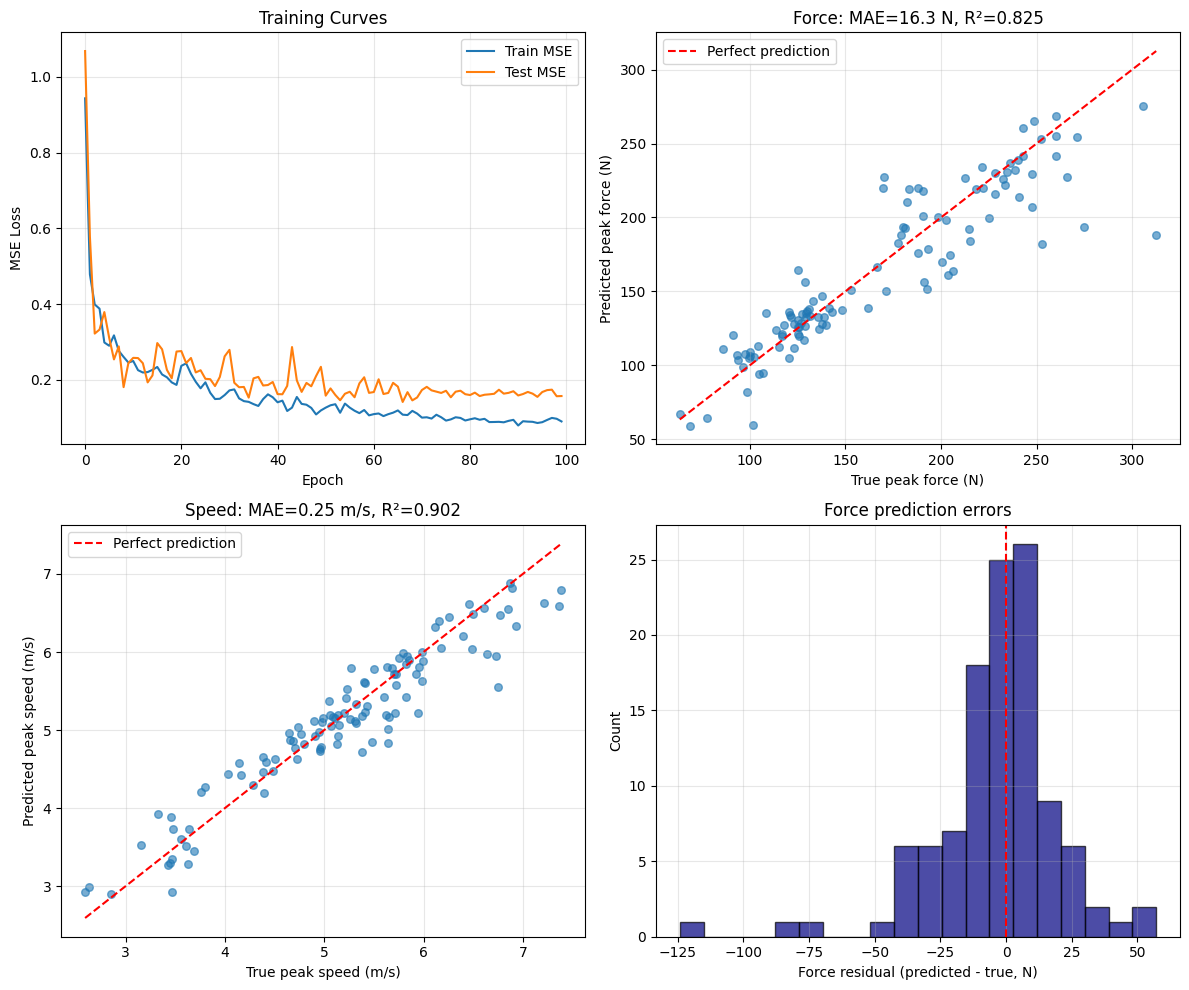


Run saved to: ../../models/tcn_regression/tcn_reg_20260607_135540


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Training curves
axes[0, 0].plot(history["train_loss"], label="Train MSE")
axes[0, 0].plot(history["test_loss"], label="Test MSE")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("Training Curves")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Force predictions
ax = axes[0, 1]
ax.scatter(best_targets[:, 0], best_preds[:, 0], alpha=0.6, s=30)
min_val, max_val = best_targets[:, 0].min(), best_targets[:, 0].max()
ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
ax.set_xlabel("True peak force (N)")
ax.set_ylabel("Predicted peak force (N)")
ax.set_title(f"Force: MAE={metrics['force_N_mae']:.1f} N, R²={metrics['force_N_r2']:.3f}")
ax.legend()
ax.grid(alpha=0.3)

# Speed predictions
ax = axes[1, 0]
ax.scatter(best_targets[:, 1], best_preds[:, 1], alpha=0.6, s=30)
min_val, max_val = best_targets[:, 1].min(), best_targets[:, 1].max()
ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
ax.set_xlabel("True peak speed (m/s)")
ax.set_ylabel("Predicted peak speed (m/s)")
ax.set_title(f"Speed: MAE={metrics['speed_mps_mae']:.2f} m/s, R²={metrics['speed_mps_r2']:.3f}")
ax.legend()
ax.grid(alpha=0.3)

# Force residuals
ax = axes[1, 1]
force_residuals = best_preds[:, 0] - best_targets[:, 0]
ax.hist(force_residuals, bins=20, alpha=0.7, color="navy", edgecolor="black")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Force residual (predicted - true, N)")
ax.set_ylabel("Count")
ax.set_title("Force prediction errors")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / "predictions.png", dpi=120, bbox_inches="tight")
plt.show()

# Save metrics
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(run_dir / "metrics.csv", index=False)
print(f"\nRun saved to: {run_dir}")

## Subject-Level Cross-Validation

Proper evaluation: train on N-1 subjects, test on 1, rotate through all subjects.
Each fold tests on a completely unseen subject. This measures real generalization.

Set `RUN_CV = True` to execute (after you have ≥3 subjects in the dataset).

In [8]:
RUN_CV = True  # set to True when you have 3+ subjects annotated

if RUN_CV:
    subjects = sorted(labels_df["subject_id"].unique())
    n_folds = len(subjects)
    
    if n_folds < 2:
        raise ValueError(f"Need at least 2 subjects for cross-validation, found {n_folds}")
    
    print(f"Running {n_folds}-fold subject-level cross-validation")
    print(f"Subjects: {subjects}\n")
    
    cv_results = []
    all_preds = []
    all_targets = []
    all_test_subjects = []
    
    cv_run_name = f"tcn_reg_cv_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    cv_dir = MODELS_DIR / cv_run_name
    cv_dir.mkdir(parents=True, exist_ok=True)
    
    for fold_idx, test_subject in enumerate(subjects):
        train_subjects = [s for s in subjects if s != test_subject]
        
        train_df_fold = labels_df[labels_df["subject_id"].isin(train_subjects)].copy()
        test_df_fold = labels_df[labels_df["subject_id"] == test_subject].copy()
        
        print(f"--- Fold {fold_idx + 1}/{n_folds}: test={test_subject} ---")
        print(f"    Train clips: {len(train_df_fold)} | Test clips: {len(test_df_fold)}")
        
        # Compute normalization stats from train only
        target_mean_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].mean().values
        target_std_fold = train_df_fold[["peak_force_N", "peak_speed_mps"]].std().values
        target_mean_t = torch.tensor(target_mean_fold, dtype=torch.float32).to(DEVICE)
        target_std_t = torch.tensor(target_std_fold, dtype=torch.float32).to(DEVICE)
        
        # Datasets and loaders
        train_ds_fold = PunchRegressionDataset(train_df_fold, CLIPS_DIR, augment=True)
        test_ds_fold = PunchRegressionDataset(test_df_fold, CLIPS_DIR, augment=False)
        train_loader_fold = DataLoader(train_ds_fold, batch_size=BATCH_SIZE,
                                        shuffle=True, num_workers=0)
        test_loader_fold = DataLoader(test_ds_fold, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=0)
        
        # Fresh model per fold
        model_fold = TCNRegressor().to(DEVICE)
        optimizer_fold = torch.optim.Adam(model_fold.parameters(),
                                          lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=EPOCHS)
        criterion_fold = nn.MSELoss()
        
        best_fold_loss = float("inf")
        best_fold_preds = None
        best_fold_targets = None
        
        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model_fold, train_loader_fold, optimizer_fold,
                                          criterion_fold, DEVICE, target_mean_t, target_std_t)
            test_loss, preds, targets = evaluate(model_fold, test_loader_fold, criterion_fold,
                                                  DEVICE, target_mean_t, target_std_t)
            scheduler_fold.step()
            
            if test_loss < best_fold_loss:
                best_fold_loss = test_loss
                best_fold_preds = preds.copy()
                best_fold_targets = targets.copy()
                torch.save(model_fold.state_dict(),
                           cv_dir / f"fold{fold_idx + 1}_{test_subject}_best.pt")
            
            if epoch % 20 == 0:
                print(f"    Epoch {epoch:3d} | train MSE {train_loss:.3f} | test MSE {test_loss:.3f}")
        
        # Compute metrics for this fold
        fold_metrics = compute_metrics(best_fold_preds, best_fold_targets)
        fold_metrics["fold"] = fold_idx + 1
        fold_metrics["test_subject"] = test_subject
        fold_metrics["n_test_clips"] = len(test_df_fold)
        cv_results.append(fold_metrics)
        
        all_preds.append(best_fold_preds)
        all_targets.append(best_fold_targets)
        all_test_subjects.extend([test_subject] * len(best_fold_targets))
        
        print(f"    Fold {fold_idx + 1} | force MAE {fold_metrics['force_N_mae']:.1f}N "
              f"R² {fold_metrics['force_N_r2']:.3f} | speed MAE {fold_metrics['speed_mps_mae']:.2f}m/s "
              f"R² {fold_metrics['speed_mps_r2']:.3f}\n")
    
    # Aggregate across folds
    cv_df = pd.DataFrame(cv_results)
    
    print("=" * 60)
    print("CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    print(f"\nPer-fold metrics:")
    print(cv_df[["fold", "test_subject", "n_test_clips",
                 "force_N_mae", "force_N_r2",
                 "speed_mps_mae", "speed_mps_r2"]].to_string(index=False))
    
    print(f"\nAggregate (mean ± std across folds):")
    metric_cols = ["force_N_mae", "force_N_rmse", "force_N_r2",
                   "speed_mps_mae", "speed_mps_rmse", "speed_mps_r2"]
    for col in metric_cols:
        mean_val = cv_df[col].mean()
        std_val = cv_df[col].std()
        print(f"  {col}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Save CV results
    cv_df.to_csv(cv_dir / "cv_results.csv", index=False)
    print(f"\nResults saved to: {cv_dir}")
    
    # Pool all predictions across folds for combined visualization
    pooled_preds = np.vstack(all_preds)
    pooled_targets = np.vstack(all_targets)
else:
    print("Cross-validation skipped (RUN_CV = False).")
    print("Set RUN_CV = True at the top of this cell when you have 3+ subjects annotated.")

Running 3-fold subject-level cross-validation
Subjects: ['subject01', 'subject02', 'subject03']

--- Fold 1/3: test=subject01 ---
    Train clips: 401 | Test clips: 160
    Epoch  20 | train MSE 0.165 | test MSE 1.163
    Epoch  40 | train MSE 0.119 | test MSE 1.150
    Epoch  60 | train MSE 0.105 | test MSE 1.243
    Epoch  80 | train MSE 0.101 | test MSE 1.045
    Epoch 100 | train MSE 0.083 | test MSE 1.175
    Fold 1 | force MAE 56.6N R² -0.748 | speed MAE 0.68m/s R² -0.538

--- Fold 2/3: test=subject02 ---
    Train clips: 401 | Test clips: 160
    Epoch  20 | train MSE 0.184 | test MSE 2.351
    Epoch  40 | train MSE 0.122 | test MSE 1.734
    Epoch  60 | train MSE 0.105 | test MSE 1.766
    Epoch  80 | train MSE 0.081 | test MSE 1.836
    Epoch 100 | train MSE 0.089 | test MSE 1.414
    Fold 2 | force MAE 56.8N R² -1.681 | speed MAE 0.77m/s R² -0.337

--- Fold 3/3: test=subject03 ---
    Train clips: 320 | Test clips: 241
    Epoch  20 | train MSE 0.186 | test MSE 2.737
    Epoc

## Cross-Validation Visualization

Pooled predictions across all folds, plus per-fold metric comparison.

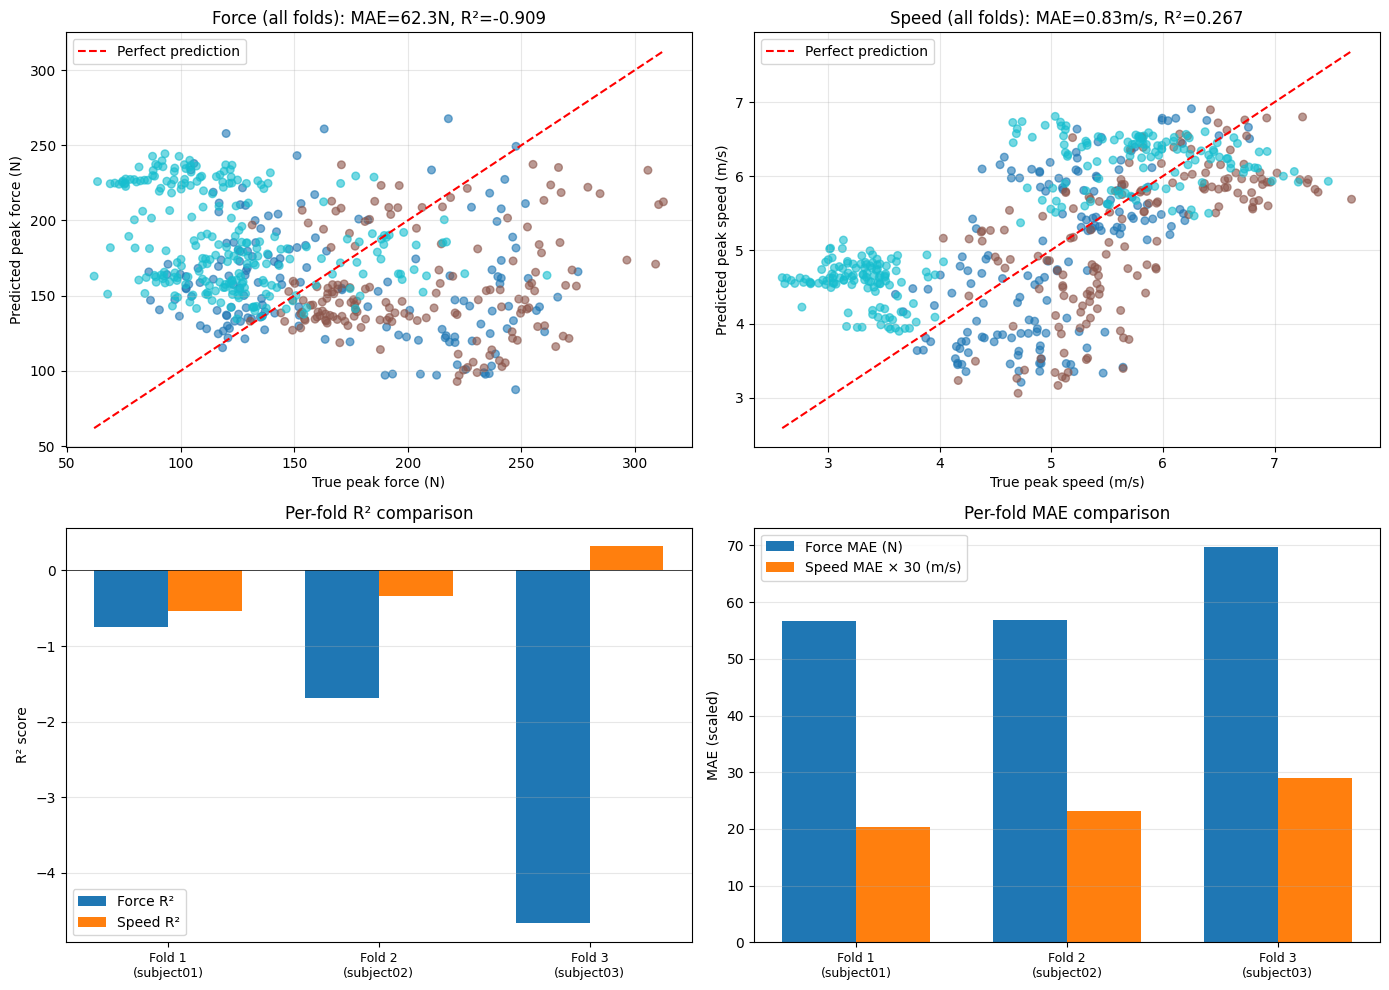


Subject color legend (in pooled scatter):
  subject01: [0.12156863 0.46666667 0.70588235 1.        ]
  subject02: [0.54901961 0.3372549  0.29411765 1.        ]
  subject03: [0.09019608 0.74509804 0.81176471 1.        ]


In [9]:
if RUN_CV and len(cv_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Pooled force predictions
    ax = axes[0, 0]
    subject_colors = plt.cm.tab10(np.linspace(0, 1, len(subjects)))
    color_map = dict(zip(subjects, subject_colors))
    colors_per_point = [color_map[s] for s in all_test_subjects]
    
    ax.scatter(pooled_targets[:, 0], pooled_preds[:, 0],
               c=colors_per_point, alpha=0.6, s=30)
    min_val, max_val = pooled_targets[:, 0].min(), pooled_targets[:, 0].max()
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak force (N)")
    ax.set_ylabel("Predicted peak force (N)")
    pooled_force_r2 = r2_score(pooled_targets[:, 0], pooled_preds[:, 0])
    pooled_force_mae = mean_absolute_error(pooled_targets[:, 0], pooled_preds[:, 0])
    ax.set_title(f"Force (all folds): MAE={pooled_force_mae:.1f}N, R²={pooled_force_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Pooled speed predictions
    ax = axes[0, 1]
    ax.scatter(pooled_targets[:, 1], pooled_preds[:, 1],
               c=colors_per_point, alpha=0.6, s=30)
    min_val, max_val = pooled_targets[:, 1].min(), pooled_targets[:, 1].max()
    ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("True peak speed (m/s)")
    ax.set_ylabel("Predicted peak speed (m/s)")
    pooled_speed_r2 = r2_score(pooled_targets[:, 1], pooled_preds[:, 1])
    pooled_speed_mae = mean_absolute_error(pooled_targets[:, 1], pooled_preds[:, 1])
    ax.set_title(f"Speed (all folds): MAE={pooled_speed_mae:.2f}m/s, R²={pooled_speed_r2:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Per-fold R² comparison
    ax = axes[1, 0]
    fold_labels = [f"Fold {r['fold']}\n({r['test_subject']})" for r in cv_results]
    x = np.arange(len(fold_labels))
    width = 0.35
    ax.bar(x - width/2, [r["force_N_r2"] for r in cv_results], width, label="Force R²")
    ax.bar(x + width/2, [r["speed_mps_r2"] for r in cv_results], width, label="Speed R²")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_ylabel("R² score")
    ax.set_title("Per-fold R² comparison")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    # Per-fold MAE comparison
    ax = axes[1, 1]
    ax.bar(x - width/2, [r["force_N_mae"] for r in cv_results], width, label="Force MAE (N)")
    ax.bar(x + width/2,
           [r["speed_mps_mae"] * 30 for r in cv_results],  # scale speed for visibility
           width, label="Speed MAE × 30 (m/s)")
    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_ylabel("MAE (scaled)")
    ax.set_title("Per-fold MAE comparison")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.savefig(cv_dir / "cv_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    # Legend for subject colors
    print("\nSubject color legend (in pooled scatter):")
    for subj, color in color_map.items():
        print(f"  {subj}: {color}")
else:
    print("Run cross-validation first (Cell 16) to see visualizations.")